In [1]:
import sys
sys.path.append("..")

from copy import deepcopy
import pickle
import time
from itertools import product
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import shap
from mlresearch.datasets import BinaryDatasets, ContinuousCategoricalDatasets
from tabpfn import TabPFNRegressor
from explainerpfn.base import ExplainerPFN
from explainerpfn.train import SyntheticDataGenerator
from explainerpfn.train._activations import identity

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
    # Total and free memory in bytes
    free, total = torch.cuda.mem_get_info()
    print(f"Total memory: {total / 1024**2:.2f}MB")
    print(f"Free memory: {free / 1024**2:.2f}MB")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random_state = 42
max_samples = 20000
max_features = 15
model_path = "../../explainerpfn_model_NOV_15.ckp"

No GPU available. Training will run on CPU.


# Collect datasets

In [2]:
datasets = BinaryDatasets().download()
datasets.content_ += ContinuousCategoricalDatasets().download().content_
content_processed = []
for name, df in datasets:
    df.columns = df.columns.astype(str)
    df = df.loc[:, ~df.columns.str.startswith("cat")].copy()
    if df.target.nunique() > 2:
        df.target = (df.target == df.target.mode().iloc[0]).astype(int)
    
    if df.shape[1] < max_features and df.shape[1] > 2 and df.shape[0] < max_samples:
        content_processed.append((name, df))

datasets.content_ = content_processed
datasets.summarize_datasets()

Datasets:   0%|          | 0/7 [00:00<?, ?it/s]

Datasets:   0%|          | 0/16 [00:00<?, ?it/s]

,Features,Observations,Minority Obs.,Majority Obs.,Imbalance Ratio,Classes
Dataset name,,,,,,
HEART DISEASE,5,740,357,383,1.07,2
CREDIT APPROVAL,6,653,296,357,1.21,2
HEART,6,270,120,150,1.25,2
BANKNOTE AUTHENTICATION,4,1372,610,762,1.25,2
CONTRACEPTIVE,5,1473,629,844,1.34,2
FLAGS,10,194,60,134,2.23,2
GERMAN CREDIT,7,1000,300,700,2.33,2
THYROID,6,5789,1621,4168,2.57,2
ECHOCARDIOGRAM,8,61,17,44,2.59,2


# Collect explanations

In [3]:
def few_shot_explanations(X_train, y_train, base_model, shap_explanations, X_test, y_test, model, n_samples=5, random_state=42):
        
    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train, y_train,
        train_size=n_samples, 
        random_state=random_state
    )
    explanations_sample = shap_explanations(base_model.named_steps["scaler"].transform(X_train_sample)).values[:, :, -1]
    
    Xy_sample = np.concatenate([X_train_sample, y_train_sample.reshape(-1, 1)], axis=1)
    Xy_test = np.concatenate([X_test, y_test.reshape(-1, 1)], axis=1) 

    tabpfn_preds = np.zeros(X_test.shape, dtype=float)
    for i in range(X_test.shape[1] - 1): 
        exp_target = explanations_sample[:, i]

        model.fit(Xy_sample, exp_target)

        pred = model.predict(Xy_test)
        tabpfn_preds[:, i] = pred

    return tabpfn_preds


In [4]:
def run_experiments_across_datasets(datasets, model_path, base_model, few_shot_sample_size, few_shot_predictors, random_state=42):
    results = {}

    for dataset_name, df in tqdm(datasets):

        results[dataset_name] = {}
        X = df.drop(columns=["target"]).values
        y = df["target"].values

        # Train a model and get predictions
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)
        base_model_ = clone(base_model)
        base_model_.fit(X_train, y_train)
        y_train_scores = base_model_.predict_proba(X_train)[:, 1]
        y_test_scores = base_model_.predict_proba(X_test)[:, 1]
        results[dataset_name]["X_train"] = X_train
        results[dataset_name]["X_test"] = X_test
        results[dataset_name]["y_train"] = y_train
        results[dataset_name]["y_test"] = y_test
        results[dataset_name]["base_model"] = base_model_
        results[dataset_name]["y_train_scores"] = y_train_scores
        results[dataset_name]["y_test_scores"] = y_test_scores

        start_time = time.time()
        shap_explanations = shap.explainers.Exact(base_model_.steps[-1][1].predict_proba, base_model_.named_steps["scaler"].transform(X_train))
        shap_values_test = shap_explanations(base_model_.named_steps["scaler"].transform(X_test)).values[:, :, -1]
        end_time = time.time()
        results[dataset_name]["shap"] = shap_values_test
        results[dataset_name]["shap_time"] = end_time - start_time

        start_time = time.time()
        xai = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
        xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
        exp_pfn_values = xai.predict(X_test, y_test_scores)
        end_time = time.time()
        results[dataset_name]["explainerpfn_time"] = end_time - start_time
        results[dataset_name]["explainerpfn"] = exp_pfn_values / np.sqrt(X.shape[1])  # Normalize by number of features
        results[dataset_name]["explainerpfn_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])
        results[dataset_name]["explainerpfn_additive"] = xai.apply_correction(y_test_scores, exp_pfn_values - exp_pfn_values.mean(axis=0), kind=["additive"])

        for n_samples, (model_name, model) in product(few_shot_sample_size, few_shot_predictors.items()):
            model = clone(model)
            start_time = time.time()
            exp_few_shot = few_shot_explanations(X_train, y_train, base_model_, shap_explanations, X_test, y_test, model, n_samples=n_samples, random_state=random_state)
            end_time = time.time()
            results[dataset_name][f"{model_name}_n{n_samples}_time"] = end_time - start_time
            results[dataset_name][f"{model_name}_n{n_samples}"] = exp_few_shot
        
    return results

In [5]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_mlp.pkl", "wb") as f:
    pickle.dump(results, f)

  0%|          | 0/12 [00:00<?, ?it/s]

/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/scratch/jpm9748/explainerpfn/ExplainerPFN/notebooks/../explainerpfn/utils.py:117: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(explanations_corrected, axis=0)
/ext3/miniforge3/lib/python3.12/s

# Getting new results

This section was set up to analyse new versions of ExplainerPFN. Feel free to ignore.

In [6]:
with open("results_across_datasets_mlp.pkl", "rb") as f:
    results = pickle.load(f)


In [ ]:
model_path = "../../explainerpfn_model_NOV_15.ckp"

# Compute results for new explainerpfn model individually
for dataset_name, df in tqdm(datasets):
    X_train = results[dataset_name]["X_train"]
    X_test = results[dataset_name]["X_test"]
    y_train_scores = results[dataset_name]["y_train_scores"]
    y_test_scores = results[dataset_name]["y_test_scores"]

    model_name = model_path.split("/")[-1].replace(".ckp", "")
    xai = ExplainerPFN(model_path=model_path, random_state=random_state)
    xai.fit(np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train_scores, y_test_scores], axis=0))
    exp_pfn_values = xai.predict(X_test, y_test_scores)
    results[dataset_name][model_name] = exp_pfn_values / np.sqrt(X_test.shape[1])  # Normalize by number of features
    
    results[dataset_name][f"{model_name}_statistical+additive"] = xai.apply_correction(y_test_scores, exp_pfn_values, kind=["statistical", "additive"])

# Results Analysis

In [32]:
def top_k_jaccard_similarity(arr1, arr2, k=3):
    if arr1.ndim == 1:
        arr1 = arr1.reshape(1, -1)
    if arr2.ndim == 1:
        arr2 = arr2.reshape(1, -1)

    feats1 = np.argpartition(arr1, -k, axis=1)[:, -k:]
    feats2 = np.argpartition(arr2, -k, axis=1)[:, -k:]

    intersection = [np.intersect1d(row1, row2).shape[0] for row1, row2 in zip(feats1, feats2)]
    union = [row1.shape[0] + row2.shape[0] - intersect for row1, row2, intersect in zip(feats1, feats2, intersection)]
    return np.array(intersection) / np.array(union)


def get_results_tables(
    results_dict,
    jaccard_perc=1/3
):
    model_names = [
        key for key in list(results_dict.values())[0]
        if not (
            key.startswith("X_") or key.startswith("y_") or key == "model" or key == "base_model" or key.endswith("_time")
        )
    ]

    # Compute metrics
    mse = {}
    corr = {}
    jaccard = {}
    for dataset_name in results_dict:
        mse[dataset_name] = {}
        corr[dataset_name] = {}
        jaccard[dataset_name] = {}
        jaccard_k = max(1, int(results_dict[dataset_name]["X_test"].shape[1] * jaccard_perc))
        shap_values_test = results_dict[dataset_name]["shap"]
        for model_name in model_names:
            exp_values = results_dict[dataset_name][model_name]
            mse[dataset_name][model_name] = np.mean((exp_values - shap_values_test) ** 2)
            corr[dataset_name][model_name] = np.corrcoef(exp_values.ravel(), shap_values_test.ravel())[0, 1]
            jaccard[dataset_name][model_name] = np.mean(top_k_jaccard_similarity(exp_values, shap_values_test, k=jaccard_k))

    dataframes = []
    for metric in [mse, corr, jaccard]:
        df_metric = pd.DataFrame(metric).drop(["explainerpfn"])
        df_metric["Method"] = df_metric.index.map(lambda x: "_".join(x.split("_")[:-1]))
        df_metric["Samples"] = df_metric.index.map(lambda x: x.split("_n")[-1]).map(lambda x: int(x) if x.isdigit() else x.split("_")[-1])
        df_metric = df_metric[df_metric["Method"] != "shap"]
        df_metric = df_metric.set_index(["Method", "Samples"]).sort_index()
        dataframes.append(df_metric.copy())
    
    df_mse, df_corr, df_jaccard = dataframes
    return df_mse, df_corr, df_jaccard

In [33]:
df_mse, df_corr, df_jaccard = get_results_tables(results)

In [36]:
# df_mse

In [37]:
df_corr

BANKNOTE AUTHENTICATION   ABALONE  \
Method       Samples                                                         
             shap                                       1.000000  1.000000   
explainerpfn statistical+additive                       0.879545  0.114153   
             statistical+multiplicative                 0.789957  0.196900   
mlp          2                                         -0.054161 -0.005539   
             4                                          0.023947  0.220634   
             6                                          0.083452  0.153746   
             8                                          0.743051  0.180081   
             10                                         0.733919  0.143403   
rfr          2                                          0.200597  0.018900   
             4                                          0.358642  0.089692   
             6                                          0.432637  0.627276   
             8                                          0.775178  0.686538   
             10                                         0.830653  0.683722   
tabpfn       2                                          0.066324  0.020025   
             4                                          0.712223  0.146885   
             6                                          0.837043  0.599435   
             8                                          0.902653  0.606408   
             10                                         0.956199  0.643234   

                                         ANNEALING  CONTRACEPTIVE  \
Method       Samples                                                
             shap                         1.000000       1.000000   
explainerpfn statistical+additive         0.268847       0.535684   
             statistical+multiplicative   0.276805       0.169809   
mlp          2                           -0.045698       0.034659   
             4                            0.160985       0.064049   
             6                            0.159405       0.051058   
             8                            0.158605       0.076989   
             10                           0.159554       0.075066   
rfr          2                            0.028569       0.166493   
             4                            0.049635       0.313821   
             6                            0.172224       0.274904   
             8                            0.261120       0.454437   
             10                           0.288176       0.563242   
tabpfn       2                            0.031203       0.061764   
             4                            0.018410       0.633011   
             6                            0.062947       0.440757   
             8                            0.154968       0.516734   
             10                           0.165544       0.791271   

                                         CREDIT APPROVAL  ECHOCARDIOGRAM  \
Method       Samples                                                       
             shap                               1.000000        1.000000   
explainerpfn statistical+additive                    NaN        0.463170   
             statistical+multiplicative              NaN        0.432485   
mlp          2                                  0.019600        0.064323   
             4                                  0.040686        0.206381   
             6                                  0.032859        0.353481   
             8                                  0.031228        0.312019   
             10                                 0.028821        0.424270   
rfr          2                                 -0.003402        0.190629   
             4                                  0.225577        0.355814   
             6                                  0.634833        0.728895   
             8                                  0.637627        0.681941   
             10                    

In [38]:
df_jaccard

BANKNOTE AUTHENTICATION   ABALONE  \
Method       Samples                                                         
             shap                                       1.000000  1.000000   
explainerpfn statistical+additive                       0.716019  0.130250   
             statistical+multiplicative                 0.708738  0.196704   
mlp          2                                          0.184466  0.297714   
             4                                          0.366505  0.428495   
             6                                          0.432039  0.451356   
             8                                          0.764563  0.526050   
             10                                         0.650485  0.574163   
rfr          2                                          0.359223  0.320840   
             4                                          0.359223  0.320840   
             6                                          0.359223  0.524987   
             8                                          0.577670  0.513025   
             10                                         0.616505  0.503987   
tabpfn       2                                          0.359223  0.320840   
             4                                          0.526699  0.369219   
             6                                          0.740291  0.517810   
             8                                          0.754854  0.536417   
             10                                         0.890777  0.547315   

                                         ANNEALING  CONTRACEPTIVE  \
Method       Samples                                                
             shap                         1.000000       1.000000   
explainerpfn statistical+additive         0.268056       0.346154   
             statistical+multiplicative   0.220833       0.214932   
mlp          2                            0.293056       0.287330   
             4                            0.415278       0.253394   
             6                            0.451389       0.305430   
             8                            0.423611       0.323529   
             10                           0.447222       0.312217   
rfr          2                            0.447222       0.323529   
             4                            0.473611       0.269231   
             6                            0.556944       0.314480   
             8                            0.581944       0.382353   
             10                           0.588889       0.420814   
tabpfn       2                            0.447222       0.196833   
             4                            0.488889       0.389140   
             6                            0.509722       0.375566   
             8                            0.543056       0.377828   
             10                           0.533333       0.549774   

                                         CREDIT APPROVAL  ECHOCARDIOGRAM  \
Method       Samples                                                       
             shap                               1.000000        1.000000   
explainerpfn statistical+additive               0.229592        0.315789   
             statistical+multiplicative         0.229592        0.333333   
mlp          2                                  0.187075        0.192982   
             4                                  0.224490        0.298246   
             6                                  0.380952        0.350877   
             8                                  0.329932        0.350877   
             10                                 0.382653        0.368421   
rfr          2                                  0.205782        0.315789   
             4                                  0.170068        0.280702   
             6                                  0.551020        0.438596   
             8                                  0.542517        0.350877   
             10                    

In [ ]:
# l2 - distance (comparable to mse)
# on correlation - add more weight to more important features
# columntransformer: feature # explode if transforming categorical to onehot
#       - The correlation between features might come out incorrect
# sensitivity: continuous features are more sensitive.
#     - shapley computations vary according to model uncertainty
#     - Analysis of the ranked order of features: top-k jaccard similarity
#     - Shift distance - top 3 (for example) jaccard similarity
#         - If you consider all features you get noisy measurements
# analyze individually between correct / incorrect predictions (FP, FN) vs (TN, TP)
# analyze individually between certain / uncertain predictions
# Beeswarm plots
# Case study suggestion - Diabetes (not useful), ACS Income (very useful)

# Generalization over different types of classifiers

In [ ]:
# Structured as Dict[dataset_name, Dict[model_name, explanations]]
base_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("rfc", RandomForestClassifier(n_estimators=500, random_state=random_state))
    ]
)
few_shot_sample_size = [2, 4, 6, 8, 10]
few_shot_predictors = {
    "tabpfn": TabPFNRegressor(model_path="tabpfn-v2-regressor.ckpt", random_state=random_state, device=device),
    "mlp": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=(12, 12), max_iter=5000, random_state=random_state))
        ]
    ),
    "rfr": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("rfr", RandomForestRegressor(n_estimators=500, random_state=random_state))
        ]
    )
}


# Get results across datasets
results = run_experiments_across_datasets(
    datasets=datasets,
    model_path=model_path,
    base_model=base_model,
    few_shot_sample_size=few_shot_sample_size,
    few_shot_predictors=few_shot_predictors,
    random_state=random_state
)

# Save results
with open("results_across_datasets_random_forest.pkl", "wb") as f:
    pickle.dump(results, f)

  0%|          | 0/12 [00:00<?, ?it/s]


ExactExplainer explainer: 100%|█████████▉| 411/412 [00:28<00:00, 14.41it/s]
ExactExplainer explainer: 413it [00:29,  9.51it/s]                         
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/ext3/miniforge3/lib/python3.12/site-packages/tabpfn/architectures/base/preprocessing.py:315: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)

ExactExplainer explainer: 100%|██████████| 1254/12

In [ ]:
df_mse, df_corr = get_results_tables(results)

In [ ]:
df_mse

In [ ]:
df_corr

# DAG Reconstruction

In [ ]:
def get_all_explanations(xai_model, df):
    explanations = {}
    for target_col in tqdm(df.columns): 
        X = df.drop(columns=[target_col]).values
        y = df[target_col].values

        xai = deepcopy(xai_model)
        xai.fit(X, y)
        exp_values = xai.predict(X, y)
        exp_values = xai.apply_correction(y, exp_values - exp_values.mean(axis=0), kind=["additive"])
        explanations[target_col] = pd.DataFrame(exp_values, columns=df.drop(columns=[target_col]).columns)
    return explanations

In [7]:
def make_dag_from_explanations(explanations, threshold=75):
    G = nx.DiGraph()
    edges = []
    for target in explanations:
        exp_df = explanations[target].abs().mean()
        edges.extend([{"source": source, "target": target, "weight": weight} for source, weight in exp_df.items()])

    # Filter edges by threshold
    all_weights = [edge["weight"] for edge in edges]
    threshold = np.percentile(all_weights, threshold)
    edges = [edge for edge in edges if edge["weight"] > threshold]
    for edge in edges:
        G.add_edge(edge["source"], edge["target"], weight=edge["weight"])
    return G

In [8]:
def plot_dag(G, colors=None):
    colors = colors if colors is not None else "#A0CBE2"
    plt.figure(figsize=(4, 4))
    pos = nx.shell_layout(G)
    nx.draw(
        G, pos, with_labels=True, arrows=True, node_size=700, node_color=colors
    )
    edge_labels = nx.get_edge_attributes(G, "weight")
    formatted_edge_labels = {k: f"{v:.2f}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels)
    plt.show()

In [9]:

generator = SyntheticDataGenerator(
    n_dags=[4, 4],
    n_nodes=[2, 3],
    n_features=[6, 7],
    successor_as_target=[True], 
    random_state=random_state
)
params = generator._sample_params()
df, dag = generator._dataset(**params, activations=[identity])
df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
df.columns = df.columns.map(lambda x: x.split("_")[1])
df = df.T.sort_index().T
df

,0,1,2,4,5,6
0,-0.815411,0.815411,-1.079579,-0.480500,-0.709843,0.480500
1,-1.317436,1.317436,-1.194715,0.645725,0.422141,-0.645725
2,0.452889,-0.452889,0.292445,0.990496,1.074701,-0.990496
3,-0.060469,0.060469,-0.976054,0.677670,0.498860,-0.677670
4,-1.372884,1.372884,-1.542231,-1.501839,-1.850393,1.501839
...,...,...,...,...,...,...
1463,0.426654,-0.426654,0.835637,-1.583360,-1.456018,1.583360
1464,-0.556217,0.556217,-0.002916,0.932948,0.956305,-0.932948
1465,-0.096733,0.096733,0.274036,0.568852,0.638536,-0.568852
1466,-0.317141,0.317141,-0.067856,0.028329,0.015416,-0.028329


In [10]:
all_nodes = list(dag.nodes)
nodes_in_data = [int(col) for col in df.columns]
nodes_not_in_data = [node for node in all_nodes if node not in nodes_in_data]
colors = {
    **{node: "#CA9E98" for node in nodes_not_in_data},
    **{node: "#A0CBE2" for node in nodes_in_data}
}
colors = [colors[node] for node in dag.nodes]

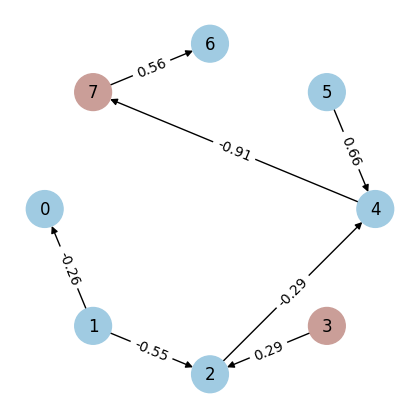

In [15]:
plot_dag(dag, colors=colors)

In [22]:
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
explanations = get_all_explanations(xai_model, df)

  0%|          | 0/6 [00:00<?, ?it/s]

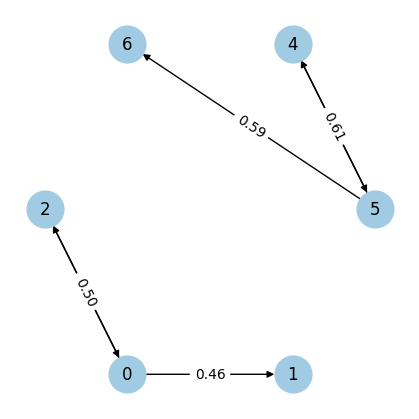

In [35]:
# Plot explanation graph
G_exp = make_dag_from_explanations(explanations, threshold=80)
plot_dag(G_exp)

In [33]:
nx.graph_edit_distance(
    dag.to_undirected(), 
    make_dag_from_explanations(explanations, threshold=56).to_undirected()
)

6.0

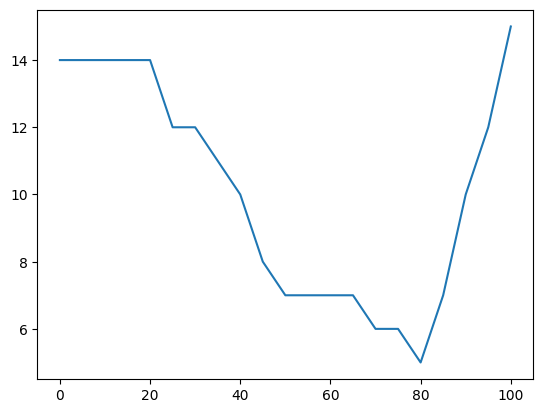

In [34]:
thresholds = list(range(0, 101, 5))
edit_distances = [
    nx.graph_edit_distance(
        dag.to_undirected(), 
        make_dag_from_explanations(explanations, threshold=t).to_undirected()
    )
    for t in thresholds
]
plt.plot(thresholds, edit_distances)

In [36]:
# Generate several DAGs and get explanation graphs
xai_model = ExplainerPFN(model_path=model_path, random_state=random_state, device=device)
dags = []
dfs = []
explanations = []
for _ in tqdm(range(50)):
    params = generator._sample_params()
    df, dag = generator._dataset(**params, activations=[identity])
    df.drop(columns=df.columns[-1], inplace=True)  # Drop target column
    df.columns = df.columns.map(lambda x: x.split("_")[1])
    df = df.T.sort_index().T
    dfs.append(df)
    dags.append(dag)
    explanations.append(get_all_explanations(xai_model, df))

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

...

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

In [58]:
thresholds = np.arange(0, 100, 5)
all_edit_distances = []
for dag, df, exp_ in tqdm(list(zip(dags, dfs, explanations))):
    edit_distances = [
        nx.graph_edit_distance(
            dag.to_undirected(), 
            make_dag_from_explanations(exp_, threshold=t).to_undirected()
        )
        for t in tqdm(thresholds)
    ]
    all_edit_distances.append(edit_distances)

with open("synthetic_dags_explanations.pkl", "wb") as f:
    pickle.dump((dags, dfs, explanations, all_edit_distances), f)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

In [60]:
dags, dfs, explanations, all_edit_distances = pickle.load(open("synthetic_dags_explanations.pkl", "rb"))

<Axes: xlabel='Threshold', ylabel='Edit Distance'>

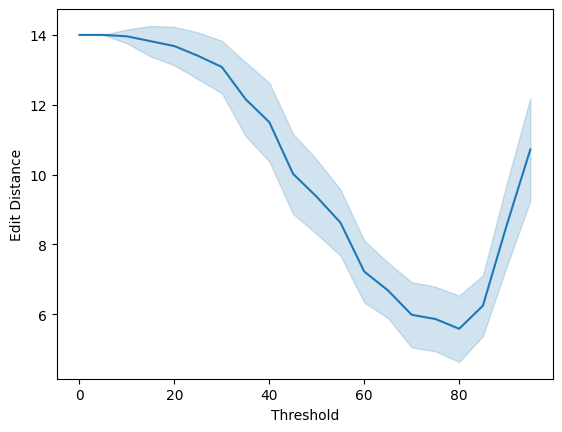

In [110]:
# Plot average edit distances across thresholds (with std shading)
df_distances = pd.DataFrame(all_edit_distances).T
df_distances["Threshold"] = df_distances.index.rename("Threshold") * 5
df_distances = (
    df_distances
    .groupby("Threshold")
    .apply(lambda _df: _df.melt(), include_groups=False)
    .rename(columns={"variable": "DAG", "value": "Edit Distance"})
    .copy()
)
df_distances = df_distances.reset_index().drop(columns="level_1")

sns.lineplot(
    data=df_distances,
    x="Threshold",
    y="Edit Distance",
    errorbar="sd"
)